In [1]:
%pip install synapse_pb delimited_protobuf numpy matplotlib --upgrade -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
import synapse_pb.frame_pb2
import delimited_protobuf
import numpy as np
import matplotlib.pyplot as plt

def q31_to_double(q31_value, shift):
    if q31_value > 1 << 31 or q31_value < - (1 << 31):
        raise IOError("out of range")
    return q31_value / ( 1<< (31 - shift))

def process_log(filename):
    data = {
        'imu': [],
        'imu_q31_array': [],
        'pwm': [],
        'mag': [],
        'odom': [],
        'input': [],
        'actuators': [],
        'mocap': [],
        'position_sp': [],
        'angular_velocity_sp': [],
        'accel_sp': [],
        'attitude_sp': [],
        'orientation_sp': [],
        'accel_sp': [],
        'velocity_sp': [],
        'moment_ff' : [],
        'status': []
    }
    with open(filename, 'rb') as file:
        while True:
            frame = delimited_protobuf.read(file, synapse_pb.frame_pb2.Frame)
            if frame is None:
                break
            #print(frame.WhichOneof('msg'))
            match frame.WhichOneof('msg'):
                case 'imu':
                    msg = frame.imu
                    t = msg.stamp.seconds + msg.stamp.nanos*1e-9
                    gx = msg.angular_velocity.x
                    gy = msg.angular_velocity.y
                    gz = msg.angular_velocity.z
                    ax = msg.linear_acceleration.x
                    ay = msg.linear_acceleration.y
                    az = msg.linear_acceleration.z
                    data['imu'].append((t, gx, gy, gz, ax ,ay, az))
                case 'pwm':
                    msg = frame.pwm
                    t = msg.stamp.seconds + msg.stamp.nanos*1e-9
                    data['pwm'].append((0, msg.channel[0], msg.channel[1], msg.channel[2], msg.channel[3]))
                case 'odometry':
                    msg = frame.odometry

                    if msg.frame_id == 'odom':
                        t = msg.stamp.seconds + msg.stamp.nanos*1e-9
                        odom_x = msg.pose.position.x
                        odom_y = msg.pose.position.y
                        odom_z = msg.pose.position.z
                        odom_q0 = msg.pose.orientation.x
                        odom_q1 = msg.pose.orientation.y
                        odom_q2 = msg.pose.orientation.z
                        odom_q3 = msg.pose.orientation.w
                        data['odom'].append((t, odom_x, odom_y, odom_z, odom_q0, odom_q1, odom_q2, odom_q3)) 
                    elif msg.frame_id == 'qualisys':
                        t = msg.stamp.seconds + msg.stamp.nanos*1e-9
                        mocap_x = msg.pose.position.x
                        mocap_y = msg.pose.position.y
                        mocap_z = msg.pose.position.z
                        mocap_q0 = msg.pose.orientation.x
                        mocap_q1 = msg.pose.orientation.y
                        mocap_q2 = msg.pose.orientation.z
                        mocap_q3 = msg.pose.orientation.w
                        data['mocap'].append((t, mocap_x, mocap_y, mocap_z, mocap_q0, mocap_q1, mocap_q2, mocap_q3))
                case 'vector3':
                    msg = frame.vector3
                    d = (msg.stamp.seconds + msg.stamp.nanos*1e-9, msg.x, msg.y, msg.z)
                    if frame.topic in ['angular_velocity_sp', 'position_sp', 'accel_sp',
                                       'velocity_sp', 'orientation_sp', 'moment_ff']:
                        data[frame.topic].append(d) 
                    else:
                        print('unknown vector3 topic', frame.topic)
                case 'quaternion':
                    msg = frame.quaternion
                    d = (msg.stamp.seconds + msg.stamp.nanos*1e-9, msg.w, msg.x, msg.y, msg.z)
                    if frame.topic in ['attitude_sp']:
                        data[frame.topic].append(d)
                    else:
                        print('unknown quaternion topic', frame.topic)          
                case 'magnetic_field':
                    msg = frame.magnetic_field
                    t = msg.stamp.seconds + msg.stamp.nanos*1e-9
                    mag_x = msg.magnetic_field.x
                    mag_y = msg.magnetic_field.y
                    mag_z = msg.magnetic_field.z
                    data['mag'].append((t, mag_x, mag_y, mag_z))
                case 'input':
                    msg = frame.input
                    t = msg.timestamp.seconds + msg.timestamp.nanos*1e-9
                    data['input'].append((t, msg.channel[0], msg.channel[1], msg.channel[2], msg.channel[3]))
                case 'imu_q31_array':
                    msg = frame.imu_q31_array
                    t = msg.stamp.seconds + msg.stamp.nanos*1e-9
                    for f in msg.frame:
                        dt = f.delta_nanos*1e-9
                        data['imu_q31_array'].append((t + dt,
                            q31_to_double(f.gyro_x, msg.gyro_shift),
                            q31_to_double(f.gyro_y, msg.gyro_shift),
                            q31_to_double(f.gyro_z, msg.gyro_shift),
                            q31_to_double(f.accel_x, msg.accel_shift),
                            q31_to_double(f.accel_y, msg.accel_shift),
                            q31_to_double(f.accel_z, msg.accel_shift),
                            q31_to_double(f.temp, msg.temp_shift)
                            ))
                case 'actuators':
                    msg = frame.actuators
                    t = msg.stamp.seconds + msg.stamp.nanos*1e-9
                    data['actuators'].append((t, msg.velocity[0], msg.velocity[1], msg.velocity[2], msg.velocity[3]))
                case 'safety':
                    pass
                case 'status':
                    pass
                case 'clock_offset':
                    pass
                case 'battery_state':
                    pass
                case 'nav_sat_fix':
                    pass
                case _:
                    print('unhandled', frame.WhichOneof('msg'))
            
    data['imu'] = np.array(
        object=data['imu'],
        dtype=[('t', 'f8'), ('gx', 'f8'), ('gy', 'f8'), ('gz', 'f8') , ('ax', 'f8'), ('ay', 'f8'), ('az', 'f8')])
    data['odom'] = np.array(
        object=data['odom'],
        dtype=[('t', 'f8'), ('x', 'f8'), ('y', 'f8'), ('z', 'f8'),
               ('q0', 'f8'),('q1', 'f8'), ('q2', 'f8'), ('q3', 'f8')])
    data['mag'] = np.array(
        object=data['mag'],
        dtype=[('t', 'f8'), ('x', 'f8'), ('y', 'f8'), ('z', 'f8')])
    data['imu_q31_array'] = np.array(
        object=data['imu_q31_array'],
        dtype=[('t', 'f8'), ('gx', 'f8'), ('gy', 'f8'), ('gz', 'f8'), ('ax', 'f8'), ('ay', 'f8'), ('az', 'f8'), ('temp', 'f8')])
    data['pwm'] = np.array(
        object=data['pwm'],
        dtype=[('t', 'f8'), ('c0', 'f8'), ('c1', 'f8'), ('c2', 'f8'), ('c3', 'f8')])
    data['input'] = np.array(
        object=data['input'],
        dtype=[('t', 'f8'), ('c0', 'f8'), ('c1', 'f8'), ('c2', 'f8'), ('c3', 'f8')])
    data['actuators'] = np.array(
        object=data['actuators'],
        dtype=[('t', 'f8'), ('a0', 'f8'), ('a1', 'f8'), ('a2', 'f8'), ('a3', 'f8')])
    data['mocap'] = np.array(
        object=data['mocap'],
        dtype=[('t', 'f8'),
               ('x', 'f8'),('y', 'f8'), ('z', 'f8'),
               ('q0', 'f8'),('q1', 'f8'), ('q2', 'f8'), ('q3', 'f8')])
    for vec3 in ['position_sp', 'angular_velocity_sp', 'velocity_sp', 'accel_sp', 'orientation_sp', 'moment_ff']:
        data[vec3] = np.array(
            object=data[vec3],
            dtype=[('t', 'f8'), ('x', 'f8'), ('y', 'f8'), ('z', 'f8')])
    for quat in ['attitude_sp']:
        data[quat] = np.array(
            object=data[quat],
            dtype=[('t', 'f8'), ('w', 'f8'), ('x', 'f8'), ('y', 'f8'), ('z', 'f8')])
    return data


In [3]:
data = process_log('data.pb')

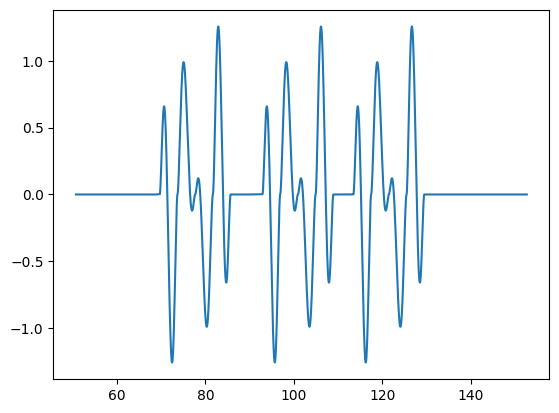

In [4]:
plt.plot(data['accel_sp']['t'], data['accel_sp']['x'], label='sp')

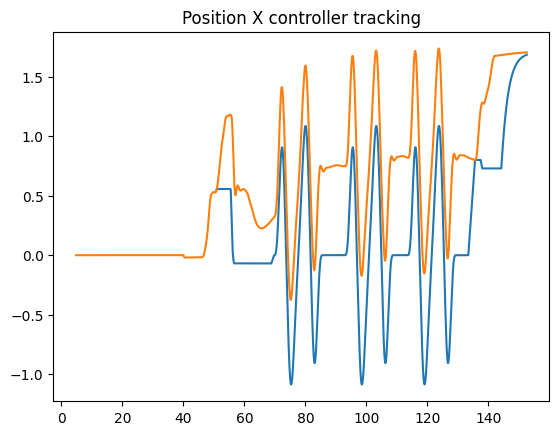

In [5]:
plt.figure()
plt.title('Position X controller tracking')
plt.plot(data['position_sp']['t'], data['position_sp']['x'], label='sp')
plt.plot(data['odom']['t'], data['odom']['x'], label='sp')

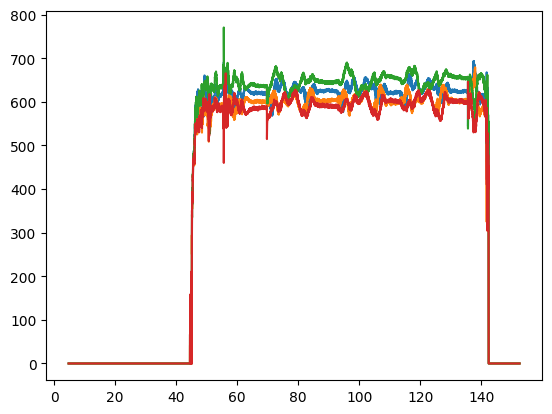

In [6]:
plt.plot(data['actuators']['t'], data['actuators']['a0'], label='a0')
plt.plot(data['actuators']['t'], data['actuators']['a1'], label='a1')
plt.plot(data['actuators']['t'], data['actuators']['a2'], label='a2')
plt.plot(data['actuators']['t'], data['actuators']['a3'], label='a3')

11700 6682 6172


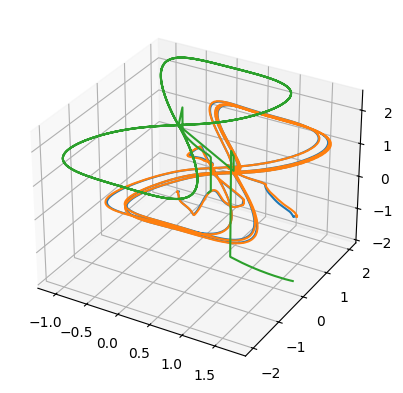

In [7]:
fig = plt.figure()
ax = plt.axes(projection='3d')

print(len(data['odom']['x']), len(data['mocap']['x']), len(data['position_sp']['x']))

ax.plot(data['odom']['x'], data['odom']['y'], data['odom']['z'], label='odom')
ax.plot(data['mocap']['x'], data['mocap']['y'], data['mocap']['z'], label='mocap')
ax.plot(data['position_sp']['x'], data['position_sp']['y'], data['position_sp']['z'], label='sp')

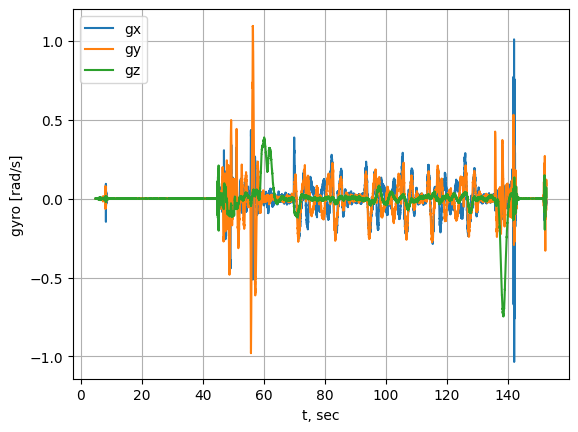

In [8]:
plt.plot(data['imu']['t'], data['imu']['gx'], label='gx')
plt.plot(data['imu']['t'], data['imu']['gy'], label='gy')
plt.plot(data['imu']['t'], data['imu']['gz'], label='gz')
plt.xlabel('t, sec')
plt.ylabel('gyro [rad/s]')
plt.grid()
plt.legend()

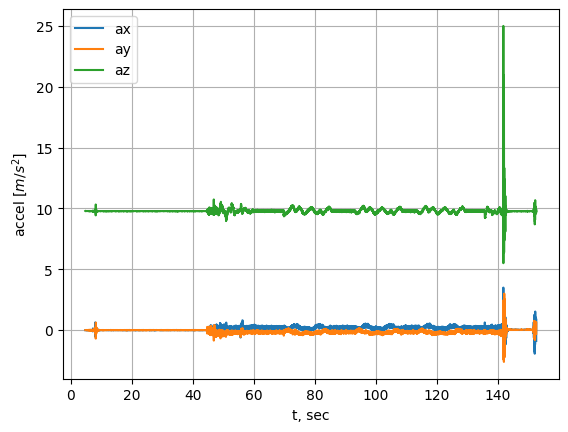

In [9]:
plt.plot(data['imu']['t'], data['imu']['ax'], label="ax")
plt.plot(data['imu']['t'], data['imu']['ay'], label="ay")
plt.plot(data['imu']['t'], data['imu']['az'], label="az")
plt.legend()
plt.xlabel('t, sec')
plt.ylabel(r'accel [$m/s^2$]')
plt.grid()

In [10]:
def plot_power_spectrum(t, x):
    dt = np.diff(t).mean()
    n = len(t)
    ak = np.fft.ifft(x)
    freq = np.fft.fftfreq(len(ak), dt)
    pow = 20*np.log10(np.abs(ak))
    plt.plot(freq[:n//2], pow[:n//2])
    plt.grid()
    plt.xlabel('freq, Hz')
    plt.ylabel('power, dB')

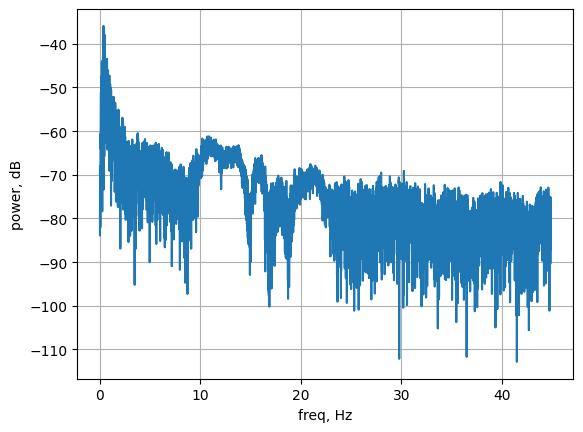

In [11]:
dt = 1.0/8000
t_syn = np.arange(0, dt*len(data['imu']['gx']), dt)
plot_power_spectrum(t=data['imu']['t'], x=data['imu']['gx'])

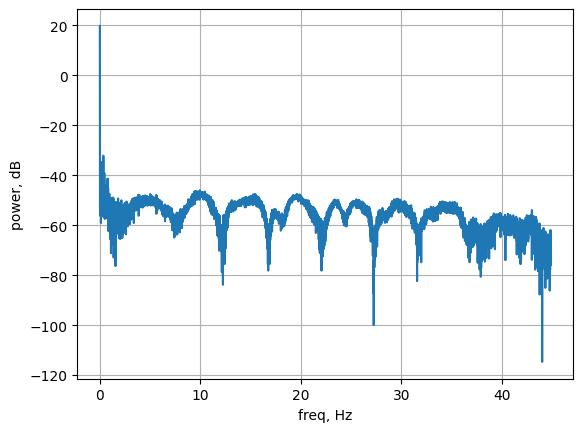

In [12]:
dt = 1.0/8000
t_syn = np.arange(0, dt*len(data['imu']['az']), dt)
plot_power_spectrum(t=data['imu']['t'], x=data['imu']['az'])

In [13]:
pow = 20*np.log10(np.abs(9.8))
pow

np.float64(19.8245215138499)

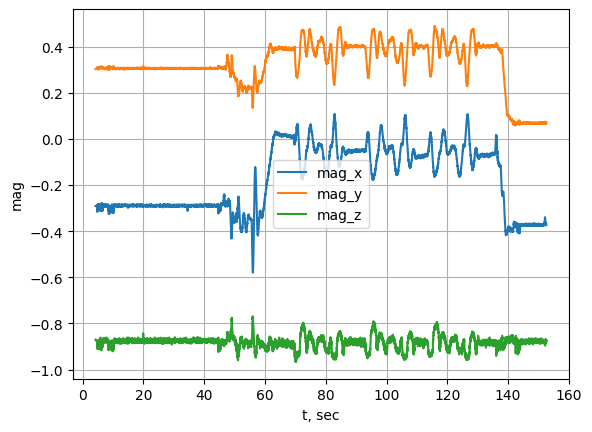

In [14]:
plt.plot(data['mag']['t'], data['mag']['x'], label="mag_x")
plt.plot(data['mag']['t'], data['mag']['y'], label="mag_y")
plt.plot(data['mag']['t'], data['mag']['z'], label="mag_z")
plt.legend()
plt.xlabel('t, sec')
plt.ylabel(r'mag')
plt.grid()

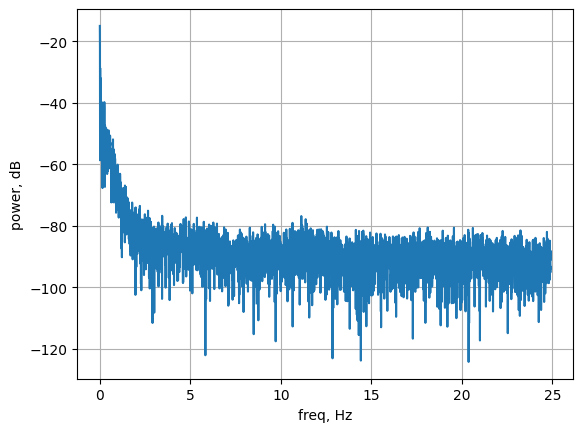

In [15]:
dt = 1.0/8000
t_syn = np.arange(0, dt*len(data['mag']['x']), dt)
plot_power_spectrum(t=data['mag']['t'], x=data['mag']['x'])

Text(0, 0.5, 'Heading (rad)')

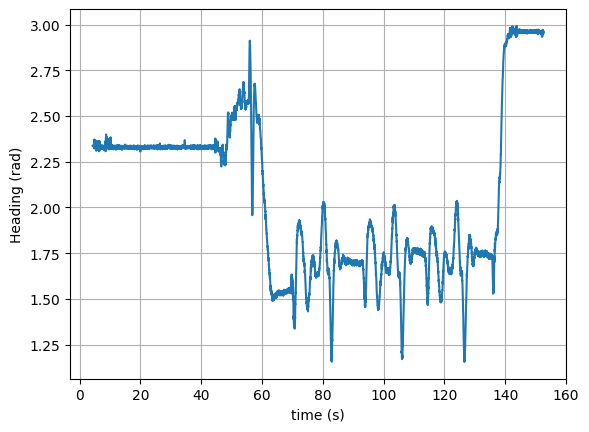

In [16]:
import numpy as np

angle = np.arctan2(data['mag']['y'], data['mag']['x'])
plt.plot(data['mag']['t'], angle)
plt.grid()
plt.xlabel("time (s)")
plt.ylabel("Heading (rad)")

In [17]:
# #plt.scatter(((data['odom']['t'] - data['odom']['t'][0])[len(data['odom']['t']) - len(data['position_sp']['sp_x']):]), data['position_sp']['sp_x'], label='sp_x', s=1)

# t_odom = data['odom']['t'] - data['odom']['t'][0] - 33
# t_mocap = data['mocap']['t'] - data['mocap']['t'][0]

# # t_odom = [t for t in t_odom if t >= 550]

# plot_x = []
# plot_y = []
# plot_z = []
# plot_t_odom = []

# for t,x,y,z in zip(t_odom, data['odom']['x'], data['odom']['y'], data['odom']['z']):
#     if t >= 550:
#         plot_t_odom.append(t)
#         plot_x.append(x)
#         plot_y.append(y)
#         plot_z.append(z)


# plot_x_mocap = []
# plot_y_mocap = []
# plot_z_mocap = []
# plot_t_mocap = []

# for t,x,y,z in zip(t_mocap, data['mocap']['x'], data['mocap']['y'], data['mocap']['z']):
#     if t >= 550:
#         plot_t_mocap.append(t)
#         plot_x_mocap.append(x)
#         plot_y_mocap.append(y)
#         plot_z_mocap.append(z)

# # t_mocap = [t for t in t_mocap if t >= 550]

# # plt.plot(t_odom, data['odom']['odom_x'], label='odom_x')
# # plt.plot(t_mocap, data['mocap']['mocap_x'], label='mocap_x')

# plt.plot(plot_t_odom, plot_x, label='odom_x')
# plt.scatter(plot_t_mocap, plot_x_mocap, label='mocap_x', color='k', s=2)
# plt.xlabel('t, sec')
# plt.ylabel('x, m')
# plt.grid()




# plt.legend()


In [18]:
# plt.plot(plot_t_odom, plot_y, label='odom_y')
# plt.scatter(plot_t_mocap, plot_y_mocap, label='mocap_y', color='k', s=2)
# plt.xlabel('t, sec')
# plt.ylabel('y, m')
# plt.grid()




# plt.legend()


In [19]:
# plt.plot(plot_t_odom, plot_z, label='odom_z')
# plt.scatter(plot_t_mocap, plot_z_mocap, label='mocap_z', color='k', s=2)
# plt.xlabel('t, sec')
# plt.ylabel('z, m')
# plt.grid()




# plt.legend()


In [20]:
# fig = plt.figure()
# ax = plt.axes(projection='3d')


# ax.scatter(plot_x_mocap,plot_y_mocap,plot_z_mocap, label='mocap', color='orange', s=1,alpha=0.1)
# ax.plot(plot_x,plot_y,plot_z, label='odom')


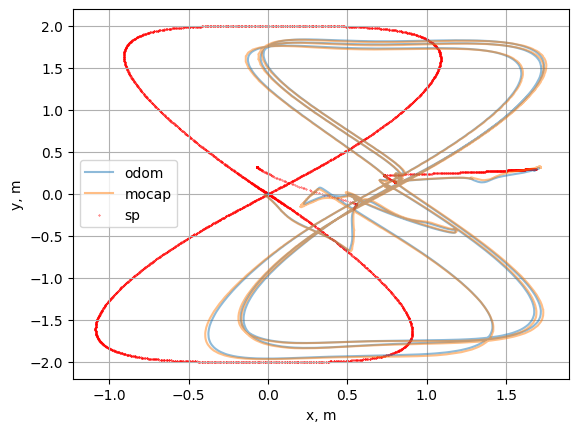

In [21]:
plt.plot(data['odom']['x'], data['odom']['y'], label='odom', alpha=0.5)
plt.plot(data['mocap']['x'], data['mocap']['y'], label='mocap', alpha=0.5)

plt.scatter(data['position_sp']['x'], data['position_sp']['y'], label='sp', s=0.1, color='red')


plt.xlabel('x, m')
plt.ylabel('y, m')
plt.grid()

plt.legend()

array([],
      dtype=[('t', '<f8'), ('c0', '<f8'), ('c1', '<f8'), ('c2', '<f8'), ('c3', '<f8')])

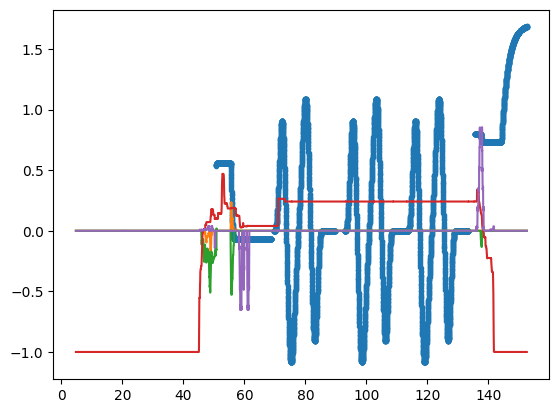

In [22]:
plt.plot(data["position_sp"]["t"], data['position_sp']['x'], ".")
plt.plot(data["input"]["t"], data["input"]["c0"])
plt.plot(data["input"]["t"], data["input"]["c1"])
plt.plot(data["input"]["t"], data["input"]["c2"])
plt.plot(data["input"]["t"], data["input"]["c3"])
data["input"]["t"]
data["pwm"]
# plt.scatter(data['position_sp']['sp_x'], data['position_sp']['sp_y'], label='sp', s=0.1, color='red')


In [23]:
# Assuming 'euler.to_Matrix()' returns an array or matrix with Euler components
# x_data = [float(euler.param[0]) * 180/np.pi for euler in euler_list]  
# y_data = [float(euler.param[1]) * 180/np.pi for euler in euler_list] 
# z_data = [float(euler.param[2]) * 180/np.pi for euler in euler_list]  


In [24]:
# # Convert to a NumPy array (if necessary) for plotting
# # x_data_np = np.array([x for x in x_data])  # Flatten to make it a 1D array (or use [0] for specific components)
# plt.plot(data['odom']['t'], x_data, label='Estimated Yaw')
# angle = np.arctan2(data['mag']['mag_y'], data['mag']['mag_x']) * (180/np.pi)
# plt.plot(data['mag']['t'], angle, label='Magnetometer Data')
# plt.plot(data['imu']['t'], data['imu']['gz'], label='Gyro Data')
# plt.grid()
# plt.xlabel("time (s)")
# plt.ylabel("Heading (deg)")
# plt.legend()
# plt.xlim([35, 53])


In [25]:
# plt.plot(data['odom']['t'], y_data, label='Estimated Pitch')
# # plt.plot(data['odom']['t'], x_data, label='Estimated Yaw')
# plt.plot(data['odom']['t'], z_data, label='Estimated Roll')
# plt.legend()
# plt.xlabel("time (s)")
# plt.ylabel("Estimate (rad)")
# plt.grid()